In [7]:
%load_ext autoreload
%autoreload 2
%autosave 30

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosaving every 30 seconds


# Plot Scores
In this notebook we will investigate the scores of the models across different leadtimes

In [8]:
import json

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import wandb

In [15]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["best", "multi leadtime"]}},
)

In [16]:
def parse_wandb_runs_to_polars(runs):
    """
    Parse WandB runs into a Polars DataFrame.
    Handles nested metrics with optional method keys (ECC, GCA, etc.)
    """
    rows = []

    for run in runs:
        run_id = run.id
        try:
            val_metrics = run.summary._json_dict["val"]
        except KeyError:
            print(f"Run {run_id} has no 'val' metrics, skipping.")
            continue
        json_config = json.loads(run.json_config)
        model_name = json_config["name"]["value"]
        # Check if metrics have method level (ECC, GCA) or not
        if any(key in val_metrics for key in ["ECC", "GCA"]):
            # Has method level (like EMOS, DRN)
            for method, method_metrics in val_metrics.items():
                if not isinstance(method_metrics, dict):
                    continue  # Skip non-dict values
                for metric_name, time_values in method_metrics.items():
                    if not isinstance(time_values, dict):
                        continue  # Skip non-dict values
                    for time_horizon, value in time_values.items():
                        # Convert time_horizon string (e.g., "24h") to hours integer
                        hours = int(time_horizon.rstrip("h"))
                        rows.append(
                            {
                                "run_id": run_id,
                                "model_name": model_name,
                                "method": method,
                                "metric_name": metric_name,
                                "timedelta_hours": hours,
                                "value": value,
                            }
                        )
        else:
            # No method level (like FM_UNET, CHEN)
            for metric_name, time_values in val_metrics.items():
                if not isinstance(time_values, dict):
                    continue  # Skip non-dict values (like _wandb metadata)
                for time_horizon, value in time_values.items():
                    # Convert time_horizon string (e.g., "24h") to hours integer
                    hours = int(time_horizon.rstrip("h"))
                    rows.append(
                        {
                            "run_id": run_id,
                            "model_name": model_name,
                            "method": None,
                            "metric_name": metric_name,
                            "timedelta_hours": hours,
                            "value": value,
                        }
                    )
    # Create Polars DataFrame with explicit Duration type
    df = (
        pl.DataFrame(rows)
        .with_columns(
            pl.col("timedelta_hours").mul(3600_000_000).cast(pl.Duration("us")).alias("timedelta")
        )
        .drop("timedelta_hours")
    )

    return df

In [17]:
df = parse_wandb_runs_to_polars(runs)
df

Run uhlr36aw has no 'val' metrics, skipping.
Run mg6my9oy has no 'val' metrics, skipping.
Run b0zvhmum has no 'val' metrics, skipping.
Run u7teygt0 has no 'val' metrics, skipping.


run_id,model_name,method,metric_name,value,timedelta
str,str,str,str,f64,duration[μs]
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.698839,5d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.37776,1d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.444331,2d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.519051,3d
"""k32mygar""","""EMOS""","""ECC""","""CRPS_10m_windspeed""",0.614189,4d
…,…,…,…,…,…
"""jrlu5t4d""","""FM_UVIT""",null,"""EnergyScore_combined""",51.069809,5d
"""jrlu5t4d""","""FM_UVIT""",null,"""EnergyScore_combined""",26.531889,1d
"""jrlu5t4d""","""FM_UVIT""",null,"""EnergyScore_combined""",31.271721,2d


In [18]:
# Prepare data for plotting using polars
df_plot = df.with_columns(
    [
        # Create combined model+method label
        pl.when(pl.col("method").is_null())
        .then(pl.col("model_name"))
        .otherwise(pl.col("model_name") + " (" + pl.col("method") + ")")
        .alias("model_method"),
        # Convert timedelta to days for better readability
        (pl.col("timedelta").dt.total_days()).alias("days"),
        # Split metric_name into score and variable
        pl.col("metric_name").str.split("_").list.first().alias("score"),
        pl.col("metric_name").str.split("_").list.slice(1).list.join("_").alias("variable"),
    ]
).sort(["score", "variable", "model_method", "days"])

df_plot

run_id,model_name,method,metric_name,value,timedelta,model_method,days,score,variable
str,str,str,str,f64,duration[μs],str,i64,str,str
"""qbuvhf5p""","""CHEN""",null,"""CRPS_10m_windspeed""",0.40017,1d,"""CHEN""",1,"""CRPS""","""10m_windspeed"""
"""qbuvhf5p""","""CHEN""",null,"""CRPS_10m_windspeed""",0.463495,2d,"""CHEN""",2,"""CRPS""","""10m_windspeed"""
"""qbuvhf5p""","""CHEN""",null,"""CRPS_10m_windspeed""",0.54157,3d,"""CHEN""",3,"""CRPS""","""10m_windspeed"""
"""qbuvhf5p""","""CHEN""",null,"""CRPS_10m_windspeed""",0.63973,4d,"""CHEN""",4,"""CRPS""","""10m_windspeed"""
"""qbuvhf5p""","""CHEN""",null,"""CRPS_10m_windspeed""",0.726599,5d,"""CHEN""",5,"""CRPS""","""10m_windspeed"""
…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",378034.40625,1d,"""Raw Ensemble""",1,"""VariogramScore""","""combined"""
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",439132.09375,2d,"""Raw Ensemble""",2,"""VariogramScore""","""combined"""
"""utgo5npv""","""Raw Ensemble""",null,"""VariogramScore_combined""",503419.78125,3d,"""Raw Ensemble""",3,"""VariogramScore""","""combined"""


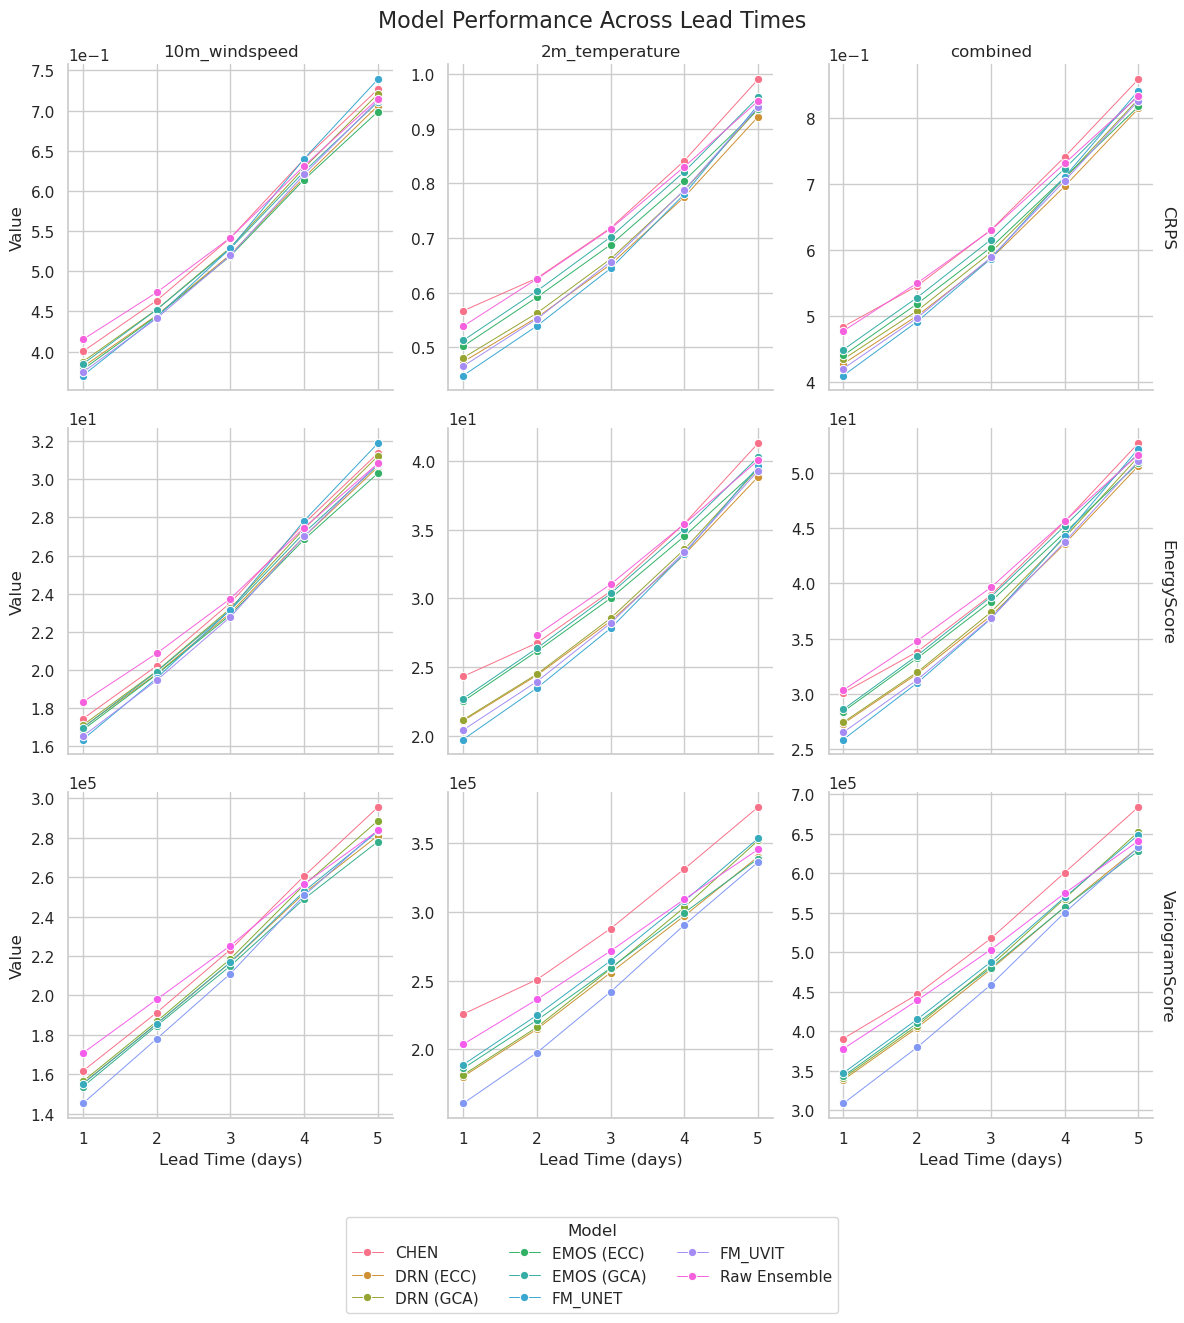

In [19]:
# Set seaborn style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")  # Use tab10 colormap

# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=3
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()